In [401]:
import warnings

warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, LSTM, Embedding,
    Input, Concatenate, Dot, Activation, Layer, TextVectorization
)
from keras.src.callbacks import EarlyStopping

### 1. Ответы на вопросы

**Механизм внимания (attention)** — это механизм, который позволяет Decoder на каждом шаге генерации обращаться ко всем скрытым состояниям Encoder и выбирать наиболее релевантные части входной последовательности. Attention вычисляет веса важности для каждого скрытого состояния Encoder и формирует контекстный вектор (context vector), который содержит наиболее полезную информацию для предсказания текущего выходного токена. Это позволяет модели эффективно использовать информацию из всей входной последовательности, а не только из одного вектора.

**Encoder** — это часть архитектуры Encoder–Decoder, которая принимает входную последовательность токенов и преобразует её в последовательность скрытых состояний. На каждом шаге Encoder обновляет своё скрытое состояние, которое хранит информацию о текущем токене и предыдущем контексте. В результате Encoder формирует набор скрытых состояний, содержащих информацию обо всей входной последовательности, а также последнее скрытое состояние, которое может использоваться как общее представление входа.

**Decoder** — это часть архитектуры, которая генерирует выходную последовательность токенов по одному шагу за раз, используя скрытое состояние Encoder, собственное предыдущее скрытое состояние и предыдущий сгенерированный токен. На каждом шаге Decoder обновляет своё скрытое состояние и предсказывает следующий токен. При использовании attention Decoder дополнительно получает контекстный вектор, сформированный на основе всех скрытых состояний Encoder, что позволяет ему учитывать наиболее важные части входной последовательности при генерации каждого выходного токена.

Недостаток Encoder–Decoder без attention заключается в том, что вся входная последовательность сжимается в один фиксированный вектор — последнее скрытое состояние Encoder. Этот вектор должен содержать всю информацию о предложении: значения слов, их порядок и контекст. Это создает информационное узкое место (information bottleneck), поскольку емкость скрытого состояния ограничена.

Механизм attention решает эту проблему, позволяя Decoder обращаться ко всем скрытым состояниям Encoder, а не только к последнему. Это означает, что при генерации каждого выходного слова Decoder может учитывать наиболее релевантные части входного предложения, что значительно улучшает качество перевода и позволяет эффективно работать с длинными последовательностями.

![](data/img.png)

### 2. Подготовка данных

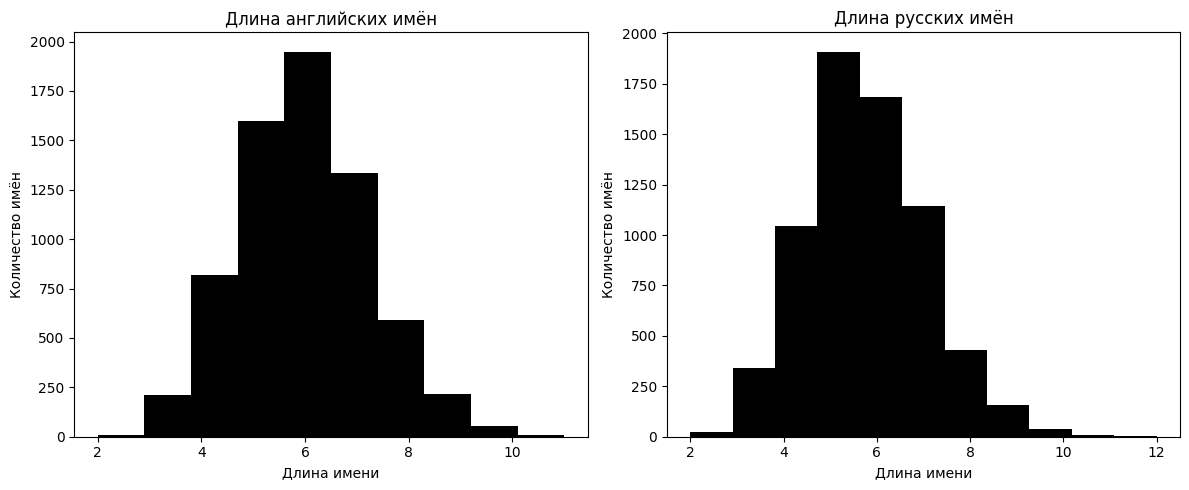

In [402]:
df = pd.read_csv('data/names.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['English'].apply(len), bins=df['English'].apply(len).max() - 1, color='black')
axes[0].set_title('Длина английских имён')
axes[0].set_xlabel('Длина имени')
axes[0].set_ylabel('Количество имён')

axes[1].hist(df['Russian'].apply(len), bins=df['Russian'].apply(len).max() - 1, color='black')
axes[1].set_title('Длина русских имён')
axes[1].set_xlabel('Длина имени')
axes[1].set_ylabel('Количество имён')

plt.tight_layout()
plt.show()

In [403]:
# Настройки
max_vocab_size = 1000
sequence_length = 12

# Английский
vectorizer_en = TextVectorization(
    max_tokens=max_vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize=None,  # важно: не ломаем имена
    split="character"  # посимвольно
)

# Русский
vectorizer_ru = TextVectorization(
    max_tokens=max_vocab_size,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize=None,
    split="character"
)

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=21)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=21)

# Добавляем спец-токены в обучающие данные
train_en = train_df["English"].tolist()
train_ru = train_df["Russian"].apply(lambda x: "^" + x + "$").tolist()

vectorizer_en.adapt(train_en)
vectorizer_ru.adapt(train_ru)

en_vocab = vectorizer_en.get_vocabulary()
ru_vocab = vectorizer_ru.get_vocabulary()

# словари
en_char2idx = {char: idx for idx, char in enumerate(en_vocab)}
ru_char2idx = {char: idx for idx, char in enumerate(ru_vocab)}

# обратные словари
en_idx2char = {idx: char for char, idx in en_char2idx.items()}
ru_idx2char = {idx: char for char, idx in ru_char2idx.items()}


def prepare_data(df):
    encoder_input = vectorizer_en(df["English"])
    decoder_input = vectorizer_ru("^" + df["Russian"])
    decoder_target = vectorizer_ru(df["Russian"] + "$")

    return encoder_input, decoder_input, decoder_target


train_enc, train_dec_in, train_dec_out = prepare_data(train_df)
val_enc, val_dec_in, val_dec_out = prepare_data(val_df)
test_enc, test_dec_in, test_dec_out = prepare_data(test_df)

### 3. Encoder

In [404]:
# Берём английские имена
names = train_df["English"].values

# добавляем спец-символы начала/конца
names = ["^" + name + "$" for name in names]

# создаём словарь символов
vocab = sorted(set("".join(names)))
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for c, i in char2idx.items()}

vocab_size = len(vocab)

seqs = []
for name in names:
    encoded = [char2idx[c] for c in name]
    seqs.append(encoded)

# создаём обучающие пары (X -> y)
X = []
y = []

for seq in seqs:
    for i in range(len(seq) - 1):
        X.append(seq[:i + 1])
        y.append(seq[i + 1])

# паддинг
max_len = max(len(x) for x in X)

X = tf.keras.preprocessing.sequence.pad_sequences(X, maxlen=max_len)
y = tf.keras.utils.to_categorical(y, num_classes=vocab_size)

In [405]:
model = Sequential([
    tf.keras.layers.Embedding(vocab_size, 64),
    LSTM(64),
    Dense(vocab_size, activation="softmax")
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

history = model.fit(
    X, y,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)]
)

Epoch 1/20
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2496 - loss: 2.5578 - val_accuracy: 0.2702 - val_loss: 2.3464
Epoch 2/20
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2915 - loss: 2.2711 - val_accuracy: 0.2875 - val_loss: 2.2654
Epoch 3/20
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3033 - loss: 2.2086 - val_accuracy: 0.2928 - val_loss: 2.2161
Epoch 4/20
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3119 - loss: 2.1701 - val_accuracy: 0.3002 - val_loss: 2.1853
Epoch 5/20
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3194 - loss: 2.1388 - val_accuracy: 0.3042 - val_loss: 2.1645
Epoch 6/20
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3282 - loss: 2.1120 - val_accuracy: 0.3095 - val_loss: 2.1493
Epoch 7/20
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3326 - loss: 2.0911 - val_accuracy: 0.3138 - val_loss: 2.1312
Epoch 8/20
1060/1060 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.3390 - loss: 2.0705 -

In [406]:
def generate_name(model, max_len=20, temperature=1.0):
    start_char = "^"
    input_seq = [char2idx[start_char]]

    result = []

    for _ in range(max_len):
        padded = tf.keras.preprocessing.sequence.pad_sequences(
            [input_seq], maxlen=max_len
        )

        preds = model.predict(padded, verbose=0)[0]

        # логиты → вероятности
        preds = np.asarray(preds).astype("float64")
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        probs = exp_preds / np.sum(exp_preds)

        next_idx = np.random.choice(len(probs), p=probs)
        next_char = idx2char[next_idx]

        if next_char == "$":
            break

        result.append(next_char)
        input_seq.append(next_idx)

    return "".join(result)


for _ in range(10):
    print(f'{_ + 1}. {generate_name(model)}')

1. Keidilley
2. Emprolyn
3. Kayverie
4. Evris
5. Derahuelll
6. Laster
7. Ediline
8. Jailia
9. Aulellon
10. Sharie


| Метод | Описание | Принцип работы |
|------|----------|----------------|
| Seq2Seq | Архитектура «encoder–decoder» на основе RNN/LSTM/GRU для преобразования одной последовательности в другую. | Энкодер последовательно обрабатывает входные данные и сжимает их в одно скрытое состояние (контекст). Декодер затем генерирует выходную последовательность, используя этот контекст. Основная проблема — потеря информации при длинных последовательностях из-за сжатия в один вектор. |
| Seq2Seq + Attention | Расширение Seq2Seq с механизмом внимания, позволяющее учитывать разные части входной последовательности. | При генерации каждого токена декодер вычисляет веса важности для всех скрытых состояний энкодера. Формируется контекст как взвешенная сумма этих состояний, что позволяет модели «смотреть» на разные части входа на каждом шаге. |
| Positional Encoding | Метод добавления информации о позиции токенов в последовательности. | К эмбеддингу каждого токена добавляется вектор позиции, обычно с использованием синусоидальных функций. Это даёт модели информацию о порядке слов, так как сама архитектура (например, Transformer) не учитывает его явно. |
| Learnable Positional Embeddings | Альтернативный способ задания позиций через обучаемые вектора. | Для каждой позиции создаётся отдельный обучаемый embedding. Он суммируется с embedding токена и обновляется в процессе обучения, позволяя модели адаптировать представление позиций под данные. |
| Multi-Head Attention | Расширенный механизм attention с несколькими параллельными «головами». | Входные данные проецируются в несколько подпространств. В каждом из них независимо вычисляется attention (через Q, K, V), после чего результаты объединяются. Это позволяет модели улавливать разные типы зависимостей одновременно. |

### 4. Seq2Seq

In [407]:
# Размер словарей
vocab_en = len(vectorizer_en.get_vocabulary())
vocab_ru = len(vectorizer_ru.get_vocabulary())

# Encoder
encoder_inputs = Input(shape=(None,), name="encoder_inputs")

encoder_embedding = Embedding(vocab_en, 64, name="encoder_embedding")
enc_emb = encoder_embedding(encoder_inputs)

encoder_lstm = LSTM(64, return_sequences=True, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

encoder_states = [state_h, state_c]

# Модель encoder
encoder_model = Model(encoder_inputs, encoder_states)

# Decoder (training)
decoder_inputs = Input(shape=(None,), name="decoder_inputs")

decoder_embedding = Embedding(vocab_ru, 64, name="decoder_embedding")
dec_emb = decoder_embedding(decoder_inputs)

decoder_lstm = LSTM(
    64,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

decoder_dense = Dense(
    vocab_ru,
    activation="softmax",
    name="decoder_dense"
)

decoder_outputs = decoder_dense(decoder_outputs)

In [408]:
# Decoder (inference)

# входные состояния
decoder_state_input_h = Input(shape=(64,))
decoder_state_input_c = Input(shape=(64,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# вход токена
decoder_inputs_inf = Input(shape=(None,))

# embedding
dec_emb2 = decoder_embedding(decoder_inputs_inf)

# LSTM с передачей состояния
decoder_outputs_inf, state_h2, state_c2 = decoder_lstm(
    dec_emb2,
    initial_state=decoder_states_inputs
)

decoder_states = [state_h2, state_c2]

# Dense слой
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

# модель декодера
decoder_model = Model(
    [decoder_inputs_inf] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states
)


def decode_sequence(input_seq, encoder_model, decoder_model, index_word, max_len=20):
    # Получаем состояния encoder
    states_value = encoder_model.predict(input_seq, verbose=0)

    # Стартовый токен (^)
    start_index = None
    for idx, word in index_word.items():
        if word == "^":
            start_index = idx
            break

    if start_index is None:
        raise ValueError("Токен ^ (SOS) не найден в словаре")

    target_seq = np.array([[start_index]])

    decoded_words = []

    for _ in range(max_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value,
            verbose=0
        )

        # Берём последний временной шаг
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = index_word.get(sampled_token_index, "")

        # Остановка по EOS
        if sampled_word == "$":
            break

        if sampled_word != "":
            decoded_words.append(sampled_word)

        # Обновляем вход (следующий шаг)
        target_seq = np.array([[sampled_token_index]])

        # Обновляем состояния
        states_value = [h, c]

    return "".join(decoded_words)


def perplexity(model, val_enc, val_dec_in, val_dec_out, pad_token=0):
    y_pred = model.predict([val_enc, val_dec_in], verbose=0)
    # Cross-entropy по каждому элементу
    loss = tf.keras.losses.sparse_categorical_crossentropy(
        val_dec_out,
        y_pred
    )

    # Маска для исключения padding
    mask = tf.cast(tf.not_equal(val_dec_out, pad_token), tf.float32)

    # Применяем маску
    loss = loss * mask

    # Усреднённый loss 
    mean_loss = tf.reduce_sum(loss) / tf.reduce_sum(mask)

    # Perplexity
    print(tf.exp(mean_loss).numpy())


def plot_loss(history):
    plt.figure(figsize=(12, 8))

    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Сходимость функции потерь')

    plt.ylim(0, 3)

    plt.legend()
    plt.grid()
    plt.show()

In [409]:
vocab = vectorizer_ru.get_vocabulary()
index_word = {idx: word for idx, word in enumerate(vocab)}


class GenerateCallback(tf.keras.callbacks.Callback):
    def __init__(self, encoder_model, decoder_model, index_word):
        super().__init__()
        self.encoder_model = encoder_model
        self.decoder_model = decoder_model
        self.index_word = index_word

    def on_epoch_end(self, epoch, logs=None):

        if (epoch) % 5 != 0:
            return

        print(f"\n--- Генерация после {epoch + 1} эпохи ---")

        # 5 примеров из train
        print(f"--- Train ---")
        for _ in range(5):
            random_idx = random.randint(0, len(train_enc) - 1)
            input_seq = train_enc[random_idx:random_idx + 1]

            result = decode_sequence(
                input_seq,
                self.encoder_model,
                self.decoder_model,
                self.index_word
            )

            print(f'{train_df["English"].iloc[random_idx]}: {result}')

        # 5 примеров из validation
        print(f"--- Valid ---")
        for _ in range(5):
            random_idx = random.randint(0, len(val_enc) - 1)
            input_seq = val_enc[random_idx:random_idx + 1]

            result = decode_sequence(
                input_seq,
                self.encoder_model,
                self.decoder_model,
                self.index_word
            )

            print(f'{val_df["English"].iloc[random_idx]}: {result}')


generate_callback = GenerateCallback(
    encoder_model,
    decoder_model,
    index_word
)

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4848 - loss: 2.4815
--- Генерация после 1 эпохи ---
--- Train ---
Emmanuel: Кеии
Christ: Кеии
Breanna: Кеии
Garner: Кеии
Bernard: Кеии
--- Valid ---
Gertha: Кеии
Arnoldo: Кеии
Dereon: Кеии
Rolando: Кеии
Geovanni: Кеии
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.5354 - loss: 1.9012 - val_accuracy: 0.5729 - val_loss: 1.5098
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6061 - loss: 1.3852 - val_accuracy: 0.6322 - val_loss: 1.2564
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6381 - loss: 1.2130 - val_accuracy: 0.6427 - val_loss: 1.1712
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6527 - loss: 1.1438 - val_accuracy: 0.6737 - val_loss: 1.0927
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6842 - loss: 1.0544 - val_accuracy: 0.6985 - val_loss: 1.0164
Epoch 6/20
169/170 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7051 - loss: 

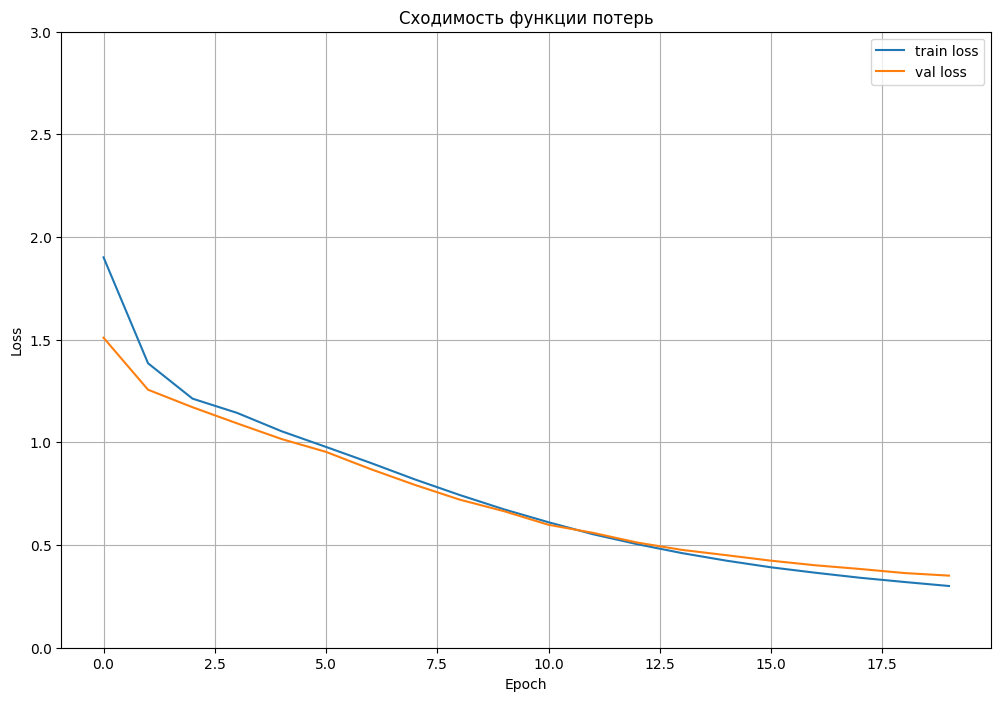

In [410]:
seq2seq = Model([encoder_inputs, decoder_inputs], decoder_outputs)

seq2seq.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = seq2seq.fit(
    [train_enc, train_dec_in],
    train_dec_out,
    validation_data=([val_enc, val_dec_in], val_dec_out),
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True), generate_callback]
)

perplexity(seq2seq, val_enc, val_dec_in, val_dec_out)
plot_loss(history)

### 5. Seq2Seq + Attention

Epoch 1/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4760 - loss: 2.4327
--- Генерация после 1 эпохи ---
--- Train ---
Sylvester: Сильферс
Martha: Марта
Trish: Трис
Norman: Норман
Payton: Пайтон
--- Valid ---
Staci: Стик
Nicolette: Нистель
Nikki: Никки
Tyrell: Тарилл
Dianne: Дианн
170/170 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.5301 - loss: 1.8822 - val_accuracy: 0.5864 - val_loss: 1.4913
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6269 - loss: 1.3299 - val_accuracy: 0.6765 - val_loss: 1.1641
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6921 - loss: 1.0801 - val_accuracy: 0.7156 - val_loss: 0.9963
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7378 - loss: 0.9231 - val_accuracy: 0.7571 - val_loss: 0.8637
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7723 - loss: 0.8072 - val_accuracy: 0.7889 - val_loss: 0.7644
Epoch 6/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.79

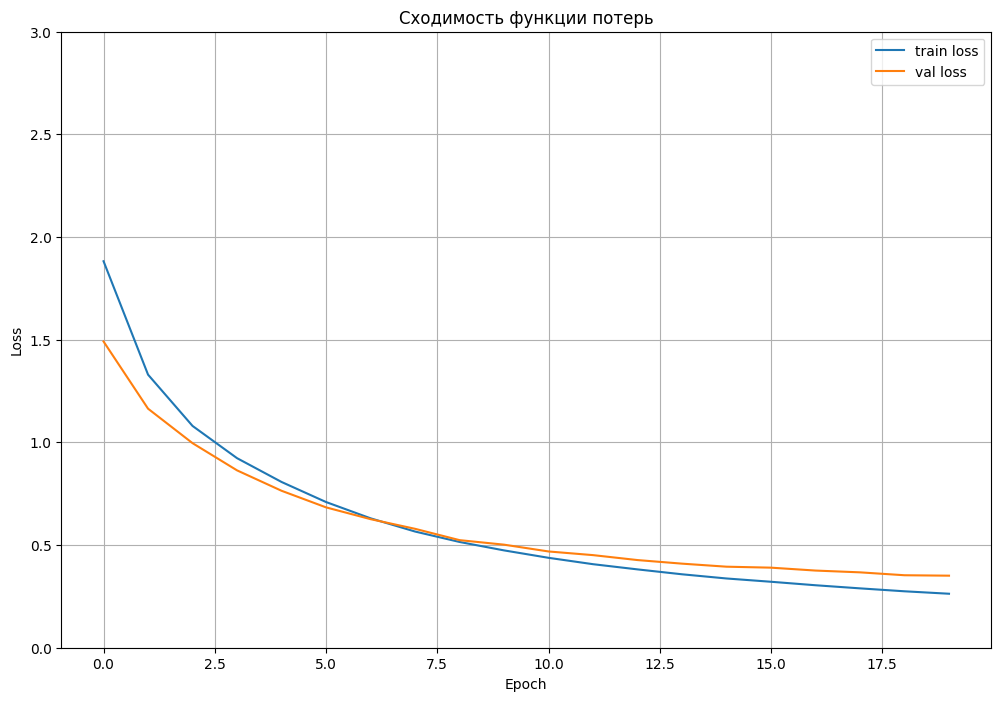

In [411]:
# Encoder
encoder_inputs = Input(shape=(None,), name="encoder_inputs")

encoder_embedding = Embedding(vocab_en, 64, name="encoder_embedding")
enc_emb = encoder_embedding(encoder_inputs)

encoder_lstm = LSTM(64, return_sequences=True, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(None,), name="decoder_inputs")

decoder_embedding = Embedding(vocab_ru, 64, name="decoder_embedding")
dec_emb = decoder_embedding(decoder_inputs)

decoder_lstm = LSTM(
    64,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

# Attention
attention = Dot(axes=[2, 2])([decoder_outputs, encoder_outputs])
attention = Activation("softmax")(attention)

context = Dot(axes=[2, 1])([attention, encoder_outputs])

# Concatenate
decoder_concat = Concatenate(axis=-1)([context, decoder_outputs])

# Финальный Dense
decoder_dense = Dense(vocab_ru, activation="softmax")
decoder_outputs_final = decoder_dense(decoder_concat)

# Model
seq2seq_attention = Model([encoder_inputs, decoder_inputs], decoder_outputs_final)

seq2seq_attention.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = seq2seq_attention.fit(
    [train_enc, train_dec_in],
    train_dec_out,
    validation_data=([val_enc, val_dec_in], val_dec_out),
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True), generate_callback]
)

perplexity(seq2seq_attention, val_enc, val_dec_in, val_dec_out)
plot_loss(history)

### 6. Positional Encoding

In [412]:
class PositionalEncoding(Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos_encoding = self._get_pos_encoding(max_len, d_model)

    def _get_pos_encoding(self, max_len, d_model):
        pos = tf.range(max_len, dtype=tf.float32)[:, tf.newaxis]
        i = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]

        angle_rates = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        angle_rads = pos * angle_rates

        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])

        pos_encoding = tf.concat([sines, cosines], axis=-1)
        return pos_encoding[tf.newaxis, ...]

    def call(self, inputs, mask=None):
        seq_len = tf.shape(inputs)[1]
        x = inputs + self.pos_encoding[:, :seq_len, :]

        # mask передаём дальше без изменений
        return x

    def compute_mask(self, inputs, mask=None):
        return mask

Epoch 1/20
166/170 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4777 - loss: 2.1659
--- Генерация после 1 эпохи ---
--- Train ---
Permelia: Пермелия
Cena: Кена
Halbert: Халберт
Garrick: Харрис
Chrissie: Крисси
--- Valid ---
Arta: Арта
Perley: Перли
Allyson: Аллисон
Earlean: Эрлан
Marisa: Мариса
170/170 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.5474 - loss: 1.7284 - val_accuracy: 0.6233 - val_loss: 1.3883
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6643 - loss: 1.2351 - val_accuracy: 0.7165 - val_loss: 1.0700
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7471 - loss: 0.9342 - val_accuracy: 0.7711 - val_loss: 0.8306
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8048 - loss: 0.7328 - val_accuracy: 0.8254 - val_loss: 0.6747
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8459 - loss: 0.5944 - val_accuracy: 0.8493 - val_loss: 0.5756
Epoch 6/20
166/170 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0

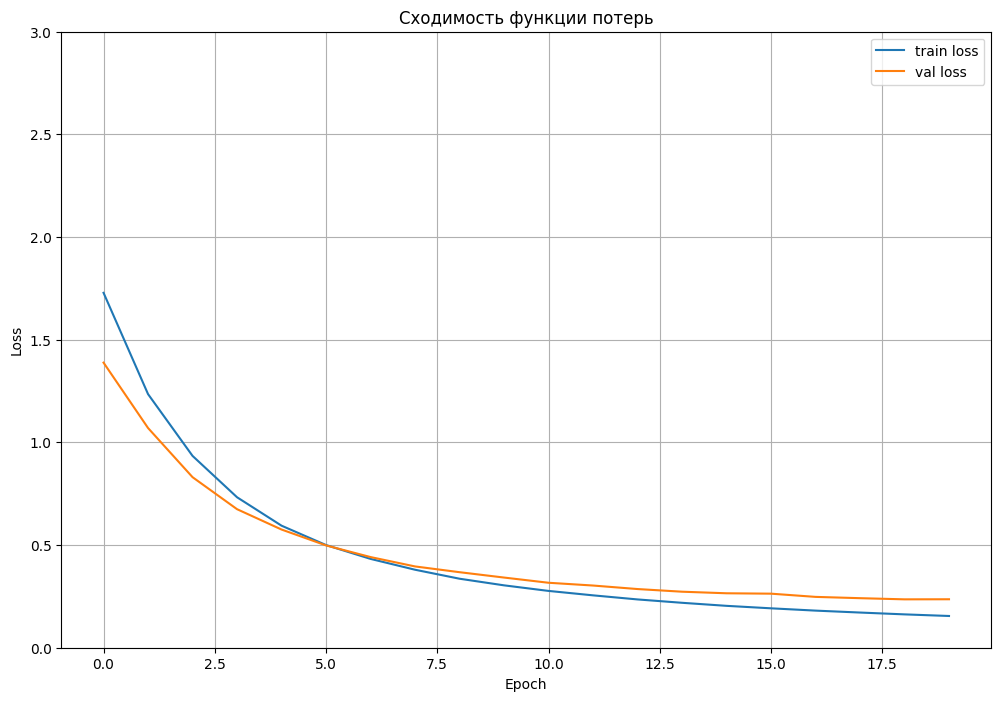

In [413]:
EMB_DIM = 64
MAX_LEN = 200

# Encoder
encoder_inputs = Input(shape=(None,), name="encoder_inputs")

enc_emb_layer = Embedding(vocab_en, EMB_DIM, mask_zero=True)
enc_emb = enc_emb_layer(encoder_inputs)

enc_pos = PositionalEncoding(MAX_LEN, EMB_DIM)(enc_emb)
encoder_outputs, state_h, state_c = encoder_lstm(enc_pos)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(None,), name="decoder_inputs")

dec_emb_layer = Embedding(vocab_ru, EMB_DIM, mask_zero=True)
dec_emb = dec_emb_layer(decoder_inputs)

dec_pos = PositionalEncoding(MAX_LEN, EMB_DIM)(dec_emb)

decoder_lstm = LSTM(
    EMB_DIM,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    dec_pos,
    initial_state=encoder_states
)

# Attention
attention_scores = Dot(axes=[2, 2])([decoder_outputs, encoder_outputs])
attention_weights = Activation("softmax")(attention_scores)

context_vector = Dot(axes=[2, 1])([attention_weights, encoder_outputs])

# Concatenation + Output
decoder_concat = Concatenate(axis=-1)([context_vector, decoder_outputs])

decoder_dense = Dense(vocab_ru, activation="softmax")
decoder_outputs_final = decoder_dense(decoder_concat)

# Model
seq2seq_pe = Model([encoder_inputs, decoder_inputs], decoder_outputs_final)

seq2seq_pe.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = seq2seq_pe.fit(
    [train_enc, train_dec_in],
    train_dec_out,
    validation_data=([val_enc, val_dec_in], val_dec_out),
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True), generate_callback]
)

perplexity(seq2seq_pe, val_enc, val_dec_in, val_dec_out)
plot_loss(history)

### 7. Learnable Positional Embeddings

In [414]:
class LearnablePositionalEmbedding(Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.max_len = max_len
        self.d_model = d_model

    def build(self, input_shape):
        self.pos_emb = self.add_weight(
            shape=(self.max_len, self.d_model),
            initializer="random_normal",
            trainable=True,
            name="pos_embedding"
        )

    def call(self, inputs):
        seq_len = tf.shape(inputs)[1]
        pos = self.pos_emb[:seq_len, :]
        pos = tf.expand_dims(pos, axis=0)

        return inputs + pos

    def compute_mask(self, inputs, mask=None):
        # просто передаём mask дальше без изменений
        return mask

Epoch 1/20
169/170 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4753 - loss: 2.4815
--- Генерация после 1 эпохи ---
--- Train ---
Treyvon: Трейдон
Camron: Камрон
Latoyia: Латиоя
Egbert: Эббен
Susann: Сюстан
--- Valid ---
Gearld: Джердл
Kelley: Келли
Mollie: Молли
Jarad: Джарда
Enzo: Энсо
170/170 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.5362 - loss: 1.8784 - val_accuracy: 0.6123 - val_loss: 1.4235
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6485 - loss: 1.2667 - val_accuracy: 0.6967 - val_loss: 1.1054
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7290 - loss: 0.9685 - val_accuracy: 0.7579 - val_loss: 0.8815
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7749 - loss: 0.7925 - val_accuracy: 0.7952 - val_loss: 0.7340
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8158 - loss: 0.6583 - val_accuracy: 0.8314 - val_loss: 0.6269
Epoch 6/20
169/170 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8405 -

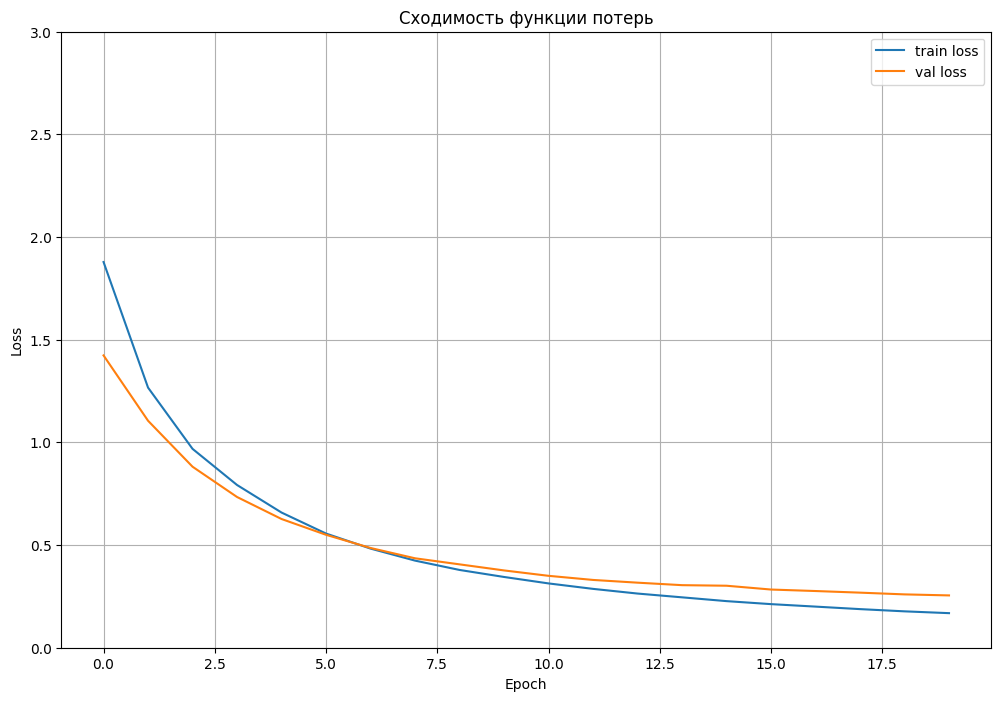

In [415]:
# Encoder
encoder_inputs = Input(shape=(None,), name="encoder_inputs")

encoder_embedding = Embedding(vocab_en, EMB_DIM, mask_zero=True)
enc_emb = encoder_embedding(encoder_inputs)

enc_emb = LearnablePositionalEmbedding(MAX_LEN, EMB_DIM)(enc_emb)

encoder_lstm = LSTM(
    EMB_DIM,
    return_sequences=True,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(None,), name="decoder_inputs")

decoder_embedding = Embedding(vocab_ru, EMB_DIM, mask_zero=True)
dec_emb = decoder_embedding(decoder_inputs)

dec_emb = LearnablePositionalEmbedding(MAX_LEN, EMB_DIM)(dec_emb)

decoder_lstm = LSTM(
    EMB_DIM,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

# Attention 
attention_scores = Dot(axes=[2, 2])([decoder_outputs, encoder_outputs])
attention_weights = Activation("softmax")(attention_scores)

context_vector = Dot(axes=[2, 1])([attention_weights, encoder_outputs])

# Concatenate + output
decoder_concat = Concatenate(axis=-1)([context_vector, decoder_outputs])

decoder_dense = Dense(vocab_ru, activation="softmax")
outputs = decoder_dense(decoder_concat)

# Model
seq2seq_le = Model([encoder_inputs, decoder_inputs], outputs)

seq2seq_le.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = seq2seq_le.fit(
    [train_enc, train_dec_in],
    train_dec_out,
    validation_data=([val_enc, val_dec_in], val_dec_out),
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True), generate_callback]
)

perplexity(seq2seq_le, val_enc, val_dec_in, val_dec_out)
plot_loss(history)

### 8. Multi-Head Attention

In [416]:
class MultiHeadAttention(Layer):
    def __init__(self, d_model, num_heads=3):
        super().__init__()
        assert d_model % num_heads == 0

        self.num_heads = num_heads
        self.depth = d_model // num_heads

        self.Wq = Dense(d_model)
        self.Wk = Dense(d_model)
        self.Wv = Dense(d_model)

        self.dense = Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q):
        batch_size = tf.shape(q)[0]

        Q = self.split_heads(self.Wq(q), batch_size)
        K = self.split_heads(self.Wk(k), batch_size)
        V = self.split_heads(self.Wv(v), batch_size)

        attention_logits = tf.matmul(Q, K, transpose_b=True)
        attention_logits /= tf.math.sqrt(tf.cast(self.depth, tf.float32))

        attention_weights = tf.nn.softmax(attention_logits, axis=-1)

        context = tf.matmul(attention_weights, V)

        context = tf.transpose(context, perm=[0, 2, 1, 3])
        context = tf.reshape(context, (batch_size, -1, self.num_heads * self.depth))

        return self.dense(context), attention_weights


Epoch 1/20
168/170 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - dense_83_accuracy: 0.4678 - loss: 2.4535
--- Генерация после 1 эпохи ---
--- Train ---
Brooklynn: Броклинн
Manson: Мэнсон
Vilma: Вилма
Patti: Пэтти
Caldonia: Клавдони
--- Valid ---
Mozella: Моклаль
Iris: Ирис
Tawny: Тэнви
Candido: Кендидо
Cale: Кэл
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - dense_83_accuracy: 0.5321 - loss: 1.8631 - val_dense_83_accuracy: 0.6059 - val_loss: 1.3691
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - dense_83_accuracy: 0.6840 - loss: 1.1242 - val_dense_83_accuracy: 0.7856 - val_loss: 0.8091
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - dense_83_accuracy: 0.8370 - loss: 0.6439 - val_dense_83_accuracy: 0.8666 - val_loss: 0.5301
Epoch 4/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - dense_83_accuracy: 0.8892 - loss: 0.4506 - val_dense_83_accuracy: 0.8968 - val_loss: 0.3971
Epoch 5/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - dense_83_accuracy: 0.9160 - loss: 0.3407 - val_dense_83_accurac

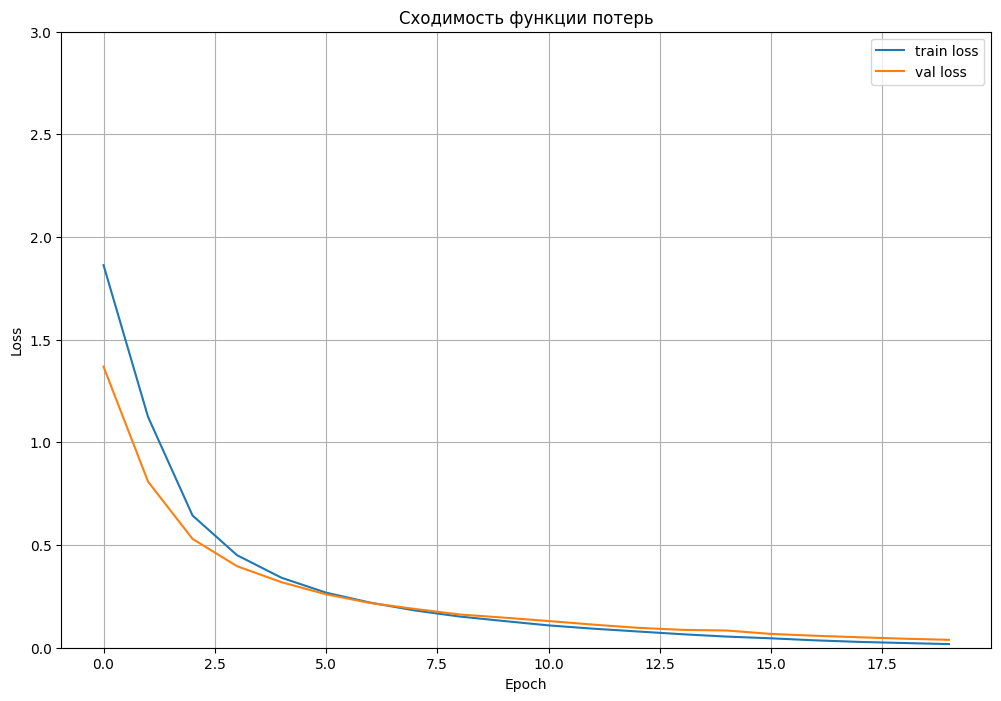

In [417]:
EMB_DIM = 60
MAX_LEN = 200

# Encoder
encoder_inputs = Input(shape=(None,), name="encoder_inputs")

enc_emb = Embedding(vocab_en, EMB_DIM, mask_zero=True)(encoder_inputs)

enc_emb = LearnablePositionalEmbedding(MAX_LEN, EMB_DIM)(enc_emb)

encoder_lstm = LSTM(
    EMB_DIM,
    return_sequences=True,
    return_state=True
)

encoder_outputs, state_h, state_c = encoder_lstm(enc_emb)

encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(None,), name="decoder_inputs")

dec_emb = Embedding(vocab_ru, EMB_DIM, mask_zero=True)(decoder_inputs)

dec_emb = LearnablePositionalEmbedding(MAX_LEN, EMB_DIM)(dec_emb)

decoder_lstm = LSTM(
    EMB_DIM,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    dec_emb,
    initial_state=encoder_states
)

# Multi-Head Attention (3 heads)
mha = MultiHeadAttention(EMB_DIM, num_heads=3)

context_vector, attention_weights = mha(
    decoder_outputs,
    encoder_outputs,
    encoder_outputs
)

# Concatenate + Output
decoder_concat = Concatenate(axis=-1)([context_vector, decoder_outputs])

decoder_dense = Dense(vocab_ru, activation="softmax")

outputs = decoder_dense(decoder_concat)

# Model (с attention)
seq2seq_multi = Model(
    [encoder_inputs, decoder_inputs],
    [outputs, attention_weights]  # важно для визуализации
)

seq2seq_multi.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=[
        "sparse_categorical_crossentropy",
        None
    ],
    metrics=[
        "accuracy",
        None
    ]
)

history = seq2seq_multi.fit(
    [train_enc, train_dec_in],
    [train_dec_out, train_dec_out],
    validation_data=(
        [val_enc, val_dec_in],
        [val_dec_out, val_dec_out]
    ),
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True), generate_callback]
)

plot_loss(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


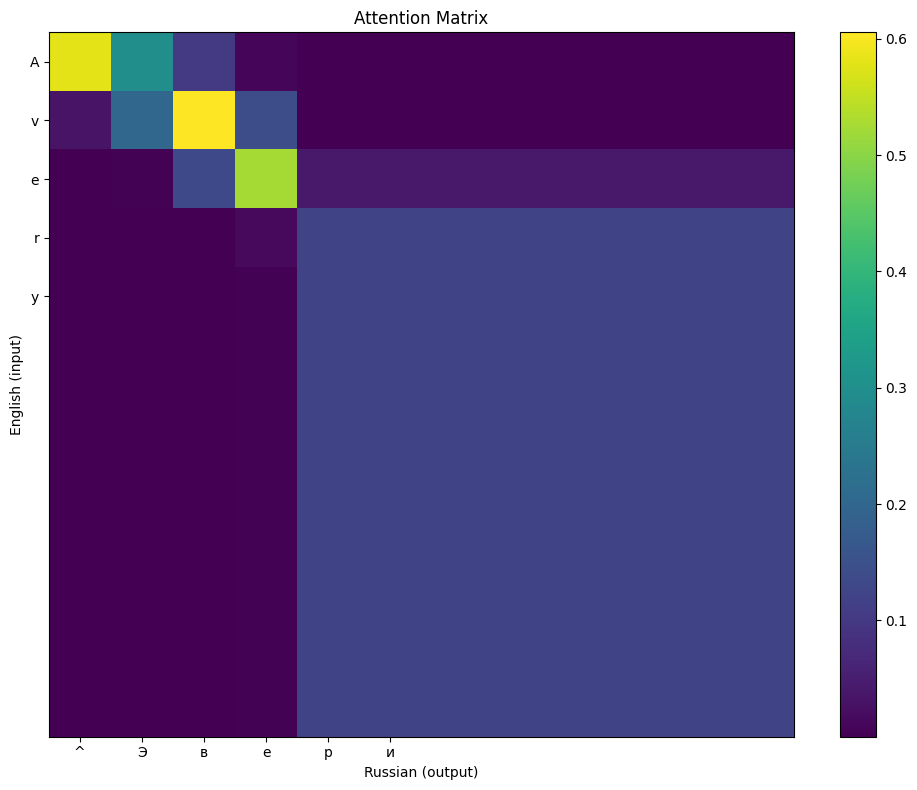

In [419]:
def ids_to_text(vectorizer, ids):
    vocab = vectorizer.get_vocabulary()
    return [vocab[i] for i in ids if i != 0]


def plot_attention(model, encoder_input, decoder_input):
    outputs, attention = model.predict([encoder_input, decoder_input])

    attn = attention[0]  # (tgt_len, src_len)

    # преобразуем входы в текст
    enc_tokens = ids_to_text(vectorizer_en, encoder_input[0])
    dec_tokens = ids_to_text(vectorizer_ru, decoder_input[0])

    plt.figure(figsize=(10, 8))

    plt.imshow(attn[1], aspect='auto')

    plt.xticks(range(len(dec_tokens)), dec_tokens)

    plt.yticks(range(len(enc_tokens)), enc_tokens)

    plt.xlabel("Russian (output)")
    plt.ylabel("English (input)")
    plt.title("Attention Matrix")

    plt.colorbar()
    plt.tight_layout()
    plt.show()


plot_attention(seq2seq_multi, test_enc[0:1], test_dec_in[0:1])